# 날씨 데이터와 함께 예측을 해봅시당~~

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from scipy.signal import savgol_filter

**Params**

In [13]:
#data slicing
start = 1440 * 1 #일차
end = start + 1440 * 1 #일간

#LSTM config
units = 128

#learning config
epochs=10
batch_size=32

**Prepare Data**

In [26]:
g_resv_flow = pd.read_csv('../data/rawdata/53.csv')
g_resv_flow.columns = ['id', 'time', 'g_resv_flow', 'drop']
del g_resv_flow['id']
del g_resv_flow['drop']

weather = pd.read_csv('../data/weather/SYNOP_AWOS_5153_MI_2023-01_2023-01_2023.csv')
weather.columns = ['time', 'temperature', 'precipitate', 'humidity']

g_resv_flow_temp = g_resv_flow[start:end]
weather_temp = weather[start:end]

time = g_resv_flow_temp['time']
time = pd.to_datetime(time)
g_resv_flow_temp['time'] = time
weather_temp['time'] = time

merged = pd.merge(g_resv_flow_temp, weather_temp, on='time')
merged.head()

,time,g_resv_flow,temperature,precipitate,humidity
0,2023-01-02 00:03:00,22,-5.2,0.0,96.5
1,2023-01-02 00:04:00,24,-5.2,0.0,96.5
2,2023-01-02 00:05:00,22,-5.1,0.0,95.7
3,2023-01-02 00:06:00,24,-5.1,0.0,95.7
4,2023-01-02 00:07:00,24,-5.1,0.0,95.7


**Preprocessing (Flow, Savitzky-Golay Filter)**

In [39]:
merged['savgol_smooth'] = savgol_filter(merged['g_resv_flow'], window_length=61, polyorder=3)

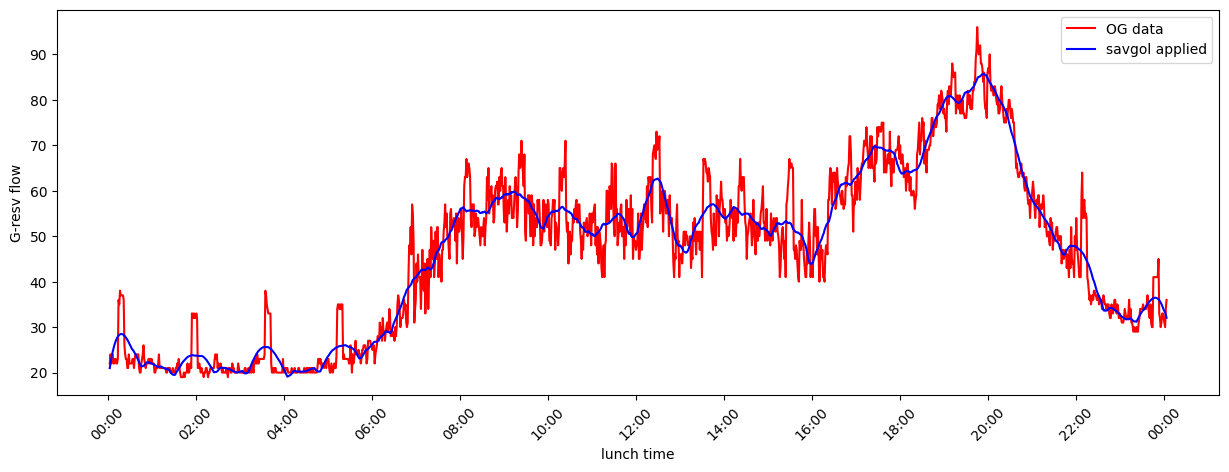

In [40]:
fig, ax = plt.subplots(figsize=(15,5))

#=========g_resv_flow
#=========g_resv_flow
#=========g_resv_flow
ax.plot(time, merged['g_resv_flow'], label='OG data', color='red')
ax.plot(time, merged['savgol_smooth'], label='savgol applied', color='blue')

#=========misc config
#=========misc config
#=========misc config
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('lunch time')
ax.set_ylabel('G-resv flow')
ax.legend()

plt.xticks(rotation=45)

plt.show()

**Check Independent Variables**
- 날씨는 계절에 따라 크게 바뀌지만, 계절 내에서는 대체로 일정하다. 타임프레임을 크게 잡고 학습시킬 때 의미가 있는 결과를 낼 것.

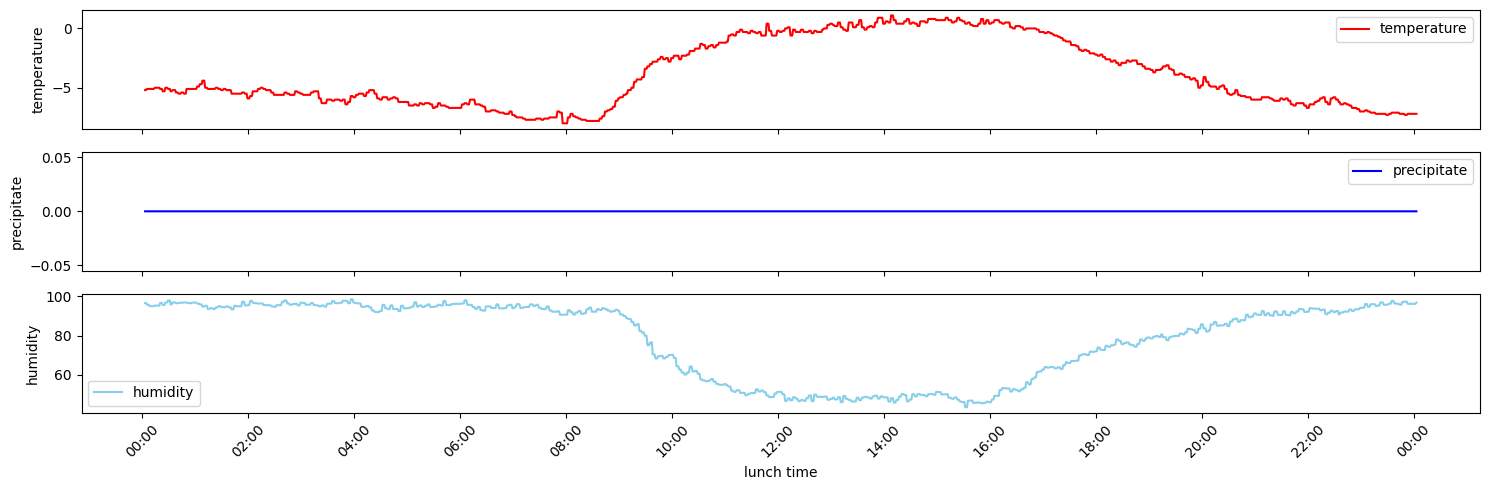

In [38]:
fig, ax = plt.subplots(figsize=(15,5), nrows=3, ncols=1, sharex=True)

#=========temperature
ax[0].plot(time, weather_temp['temperature'], label='temperature', color='red')
ax[0].set_ylabel('temperature')
ax[0].legend()

#=========precipitate
ax[1].plot(time, weather_temp['precipitate'], label='precipitate', color='blue')
ax[1].set_ylabel('precipitate')
ax[1].legend()

#=========humidity
ax[2].plot(time, weather_temp['humidity'], label='humidity', color='skyblue')
ax[2].set_ylabel('humidity')
ax[2].legend()
ax[2].set_xlabel('lunch time')

#=========misc config
for a in ax:
    a.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    a.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xticks(rotation=45)

plt.tight_layout() # Prevents labels from overlapping
plt.show()

**Data Normalization**

In [50]:
merged.columns[-4:]

Index(['temperature', 'precipitate', 'humidity', 'savgol_smooth'], dtype='str')

In [53]:
scaler = MinMaxScaler(feature_range=(0,1))

column_to_normalize = merged.columns[-4:]
merged[column_to_normalize] = scaler.fit_transform(merged[column_to_normalize])

merged.head()

,time,g_resv_flow,temperature,precipitate,humidity,savgol_smooth
0,2023-01-02 00:03:00,22,0.307692,0.0,0.965328,0.027932
1,2023-01-02 00:04:00,24,0.307692,0.0,0.965328,0.043317
2,2023-01-02 00:05:00,22,0.318681,0.0,0.950730,0.057392
3,2023-01-02 00:06:00,24,0.318681,0.0,0.950730,0.070198
4,2023-01-02 00:07:00,24,0.318681,0.0,0.950730,0.081779


In [69]:
merged[:5]

,time,g_resv_flow,temperature,precipitate,humidity,savgol_smooth
0,2023-01-02 00:03:00,22,0.307692,0.0,0.965328,0.027932
1,2023-01-02 00:04:00,24,0.307692,0.0,0.965328,0.043317
2,2023-01-02 00:05:00,22,0.318681,0.0,0.950730,0.057392
3,2023-01-02 00:06:00,24,0.318681,0.0,0.950730,0.070198
4,2023-01-02 00:07:00,24,0.318681,0.0,0.950730,0.081779


**Sliding Window Dataset**

In [55]:
def create_sliding_windows(data, window_size=60, lead_time=1, forecast_size=10):
    stop_index = len(data) - window_size - forecast_size
    X = [data[i:i+window_size] for i in range(stop_index)]
    y = [data[i+window_size : i+window_size+forecast_size] for i in range(stop_index)]

    return np.array(X), np.array(y)

In [71]:

X,y = create_sliding_windows(merged)

print(f"total windowed samples: {len(X)}")

X.shape, y.shape

total windowed samples: 1370


((1370, 60, 6), (1370, 10, 6))